In [1]:
#1 라이브러리 & 모델 불러오기

import os, sys
sys.path.append(os.path.abspath(".."))

import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from src.evaluation import evaluate_model


In [2]:
#2 모델 + 데이터 로드

# 전처리된 데이터 로드
df = pd.read_csv('../data/preprocessed.csv')
X = df['Text']; y = df['Sentiment']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ✅ 모델별 vectorizer 불러오기
vectorizers = {
    "Naive Bayes": joblib.load('../outputs/vectorizer_nb.pkl'),
    "Logistic Balanced": joblib.load('../outputs/vectorizer_logistic.pkl'),
    "RandomForest Balanced": joblib.load('../outputs/vectorizer_rf.pkl')
}

# ✅ 모델별 test 벡터 생성
X_test_vecs = {
    name: vec.transform(X_test) for name, vec in vectorizers.items()
}

# ✅ 모델 불러오기
models = {
    "Naive Bayes": joblib.load('../outputs/models/naive_bayes.pkl'),
    "Logistic Balanced": joblib.load('../outputs/models/logistic_balanced.pkl'),
    "RandomForest Balanced": joblib.load('../outputs/models/randomforest_balanced.pkl')
}



>>>>> 모델: Naive Bayes

==== Naive Bayes ====
              precision    recall  f1-score   support

           0       0.91      0.26      0.40     16407
           1       0.88      1.00      0.93     88756

    accuracy                           0.88    105163
   macro avg       0.89      0.63      0.67    105163
weighted avg       0.88      0.88      0.85    105163

ROC AUC: 0.9339


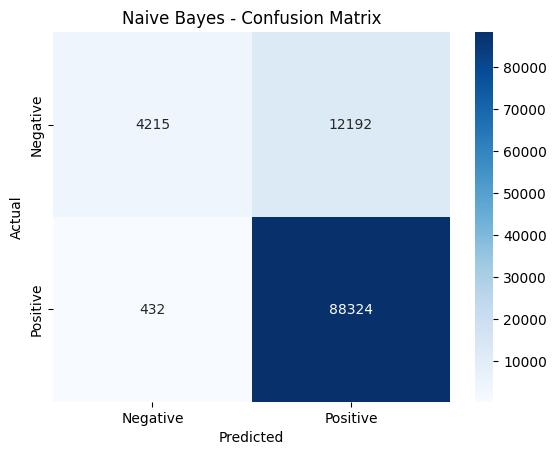


>>>>> 모델: Logistic Balanced

==== Logistic Balanced ====
              precision    recall  f1-score   support

           0       0.62      0.89      0.73     16407
           1       0.98      0.90      0.94     88756

    accuracy                           0.90    105163
   macro avg       0.80      0.90      0.83    105163
weighted avg       0.92      0.90      0.90    105163

ROC AUC: 0.9586


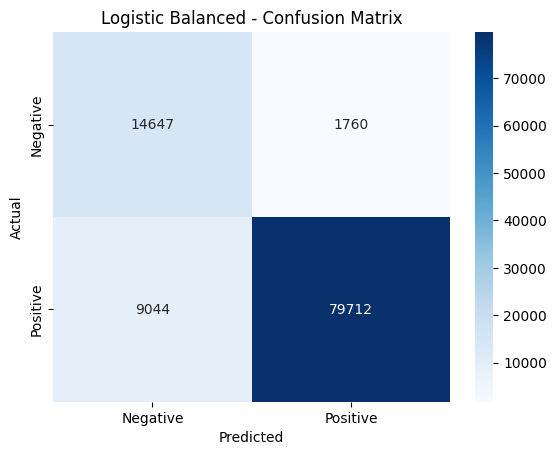


>>>>> 모델: RandomForest Balanced

==== RandomForest Balanced ====
              precision    recall  f1-score   support

           0       0.92      0.63      0.75     16407
           1       0.94      0.99      0.96     88756

    accuracy                           0.93    105163
   macro avg       0.93      0.81      0.86    105163
weighted avg       0.93      0.93      0.93    105163

ROC AUC: 0.9649


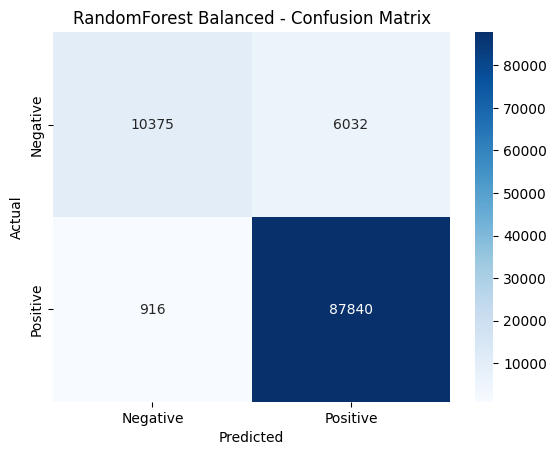

In [4]:
# 3 평가, 성능 수집

results = []
for name, model in models.items():
    print(f"\n>>>>> 모델: {name}")
    X_vec = X_test_vecs[name]     # ✅ 해당 모델용 벡터 꺼내기
    evaluate_model(name, model, X_vec, y_test)


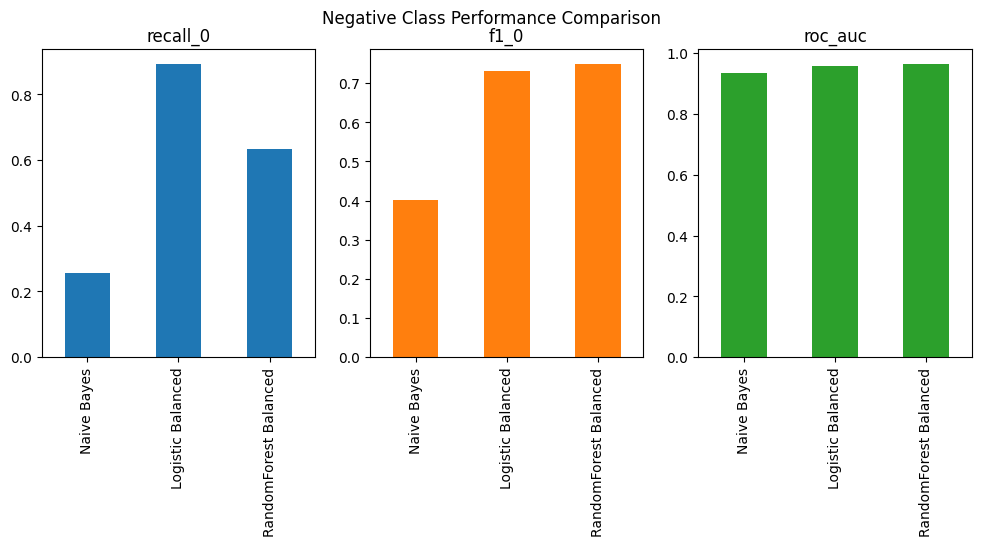

In [6]:
# 4 시각적 성능 비교
from sklearn.metrics import recall_score, f1_score, roc_auc_score
metrics = {}
for name, model in models.items():
    X_vec = X_test_vecs[name]      # ✅ 각 모델의 벡터로 바꿔치기
    y_pred = model.predict(X_vec)

    try:
        y_proba = model.predict_proba(X_vec)[:, 1]
    except:
        y_proba = None

    metrics[name] = {
        "recall_0": recall_score(y_test, y_pred, pos_label=0),
        "f1_0": f1_score(y_test, y_pred, pos_label=0),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }

dfm = pd.DataFrame(metrics).T
dfm.plot.bar(subplots=True, layout=(1,3), figsize=(12,4), legend=False)
plt.suptitle("Negative Class Performance Comparison"); plt.show()


In [ ]:
#5 결론 블록
# - **Logistic + Balanced** 모델이 부정(0)의 Recall/F1에서 가장 우수합니다.
# - Naive Bayes는 속도는 빠르지만 부정 검출이 약합니다.
# - Random Forest는 성능은 준수하나 학습 속도가 느립니다.
